# Start-up: CalorIA

## Pipeline del trabajo

<p align="center">
  <img src="pipeline_arquitectura.excalidraw.svg" alt="Pipeline de IA Nutricional" width="90%">
</p>

## Librerías

In [1]:
from food_description import FoodNutritionSystem
from user_profile import UserProfile
from nutrition_lookup import lookup_dish, analyze_meal, print_meal_summary
from meal_suggester import check_and_suggest

import json
from datetime import datetime
import os
from IPython.display import display
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/home/javier/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# EJECUTAR SOLO UNA VEZ: carga el modelo en GPU
nutrition_system = FoodNutritionSystem(unload_text_model=True)

Loading Vision Model: Qwen/Qwen2-VL-7B-Instruct on cuda...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 730/730 [00:04<00:00, 147.65it/s] 


System initialized.


## Crear el usuario

In [3]:
# ─── Configura aquí tu perfil ────────────────────────────────
user = UserProfile(
    name           = "Usuario",
    sex            = "female",        # "male" | "female"
    age            = 20,
    weight_kg      = 50.0,
    height_cm      = 165.0,
    activity_level = 3,             # entrenos/semana (0-6)
    goal           = "maintenance",  # "loss" | "maintenance" | "gain"
    restrictions   = {                   
        "allergies":    [],               # e.g. ["gluten", "nuts"]
        "intolerances": [],               # e.g. ["lactose"]
        "dislikes":     [],               # e.g. ["liver", "anchovies"]
    }
)

print(user.summary())

# Guardar en user.json con el mismo formato que espera el resto del notebook
with open("user.json", "w") as f:
    json.dump({
        "name": user.name,
        "daily_targets": {
            "kcal":      user.daily_targets["kcal"],
            "protein_g": user.daily_targets["protein_g"],
            "carbs_g":   user.daily_targets["carbs_g"],
            "fat_g":     user.daily_targets["fat_g"],
        },
        "restrictions": user.restrictions
    }, f, indent=4)

=== Usuario | Mantenimiento ===
BMR: 1270 kcal  |  TDEE: 1969 kcal
Objetivo diario: 1969 kcal
  Proteína: 90g
  Carbos:   265g
  Grasa:    61g


## Estimar alimentos y cantidades

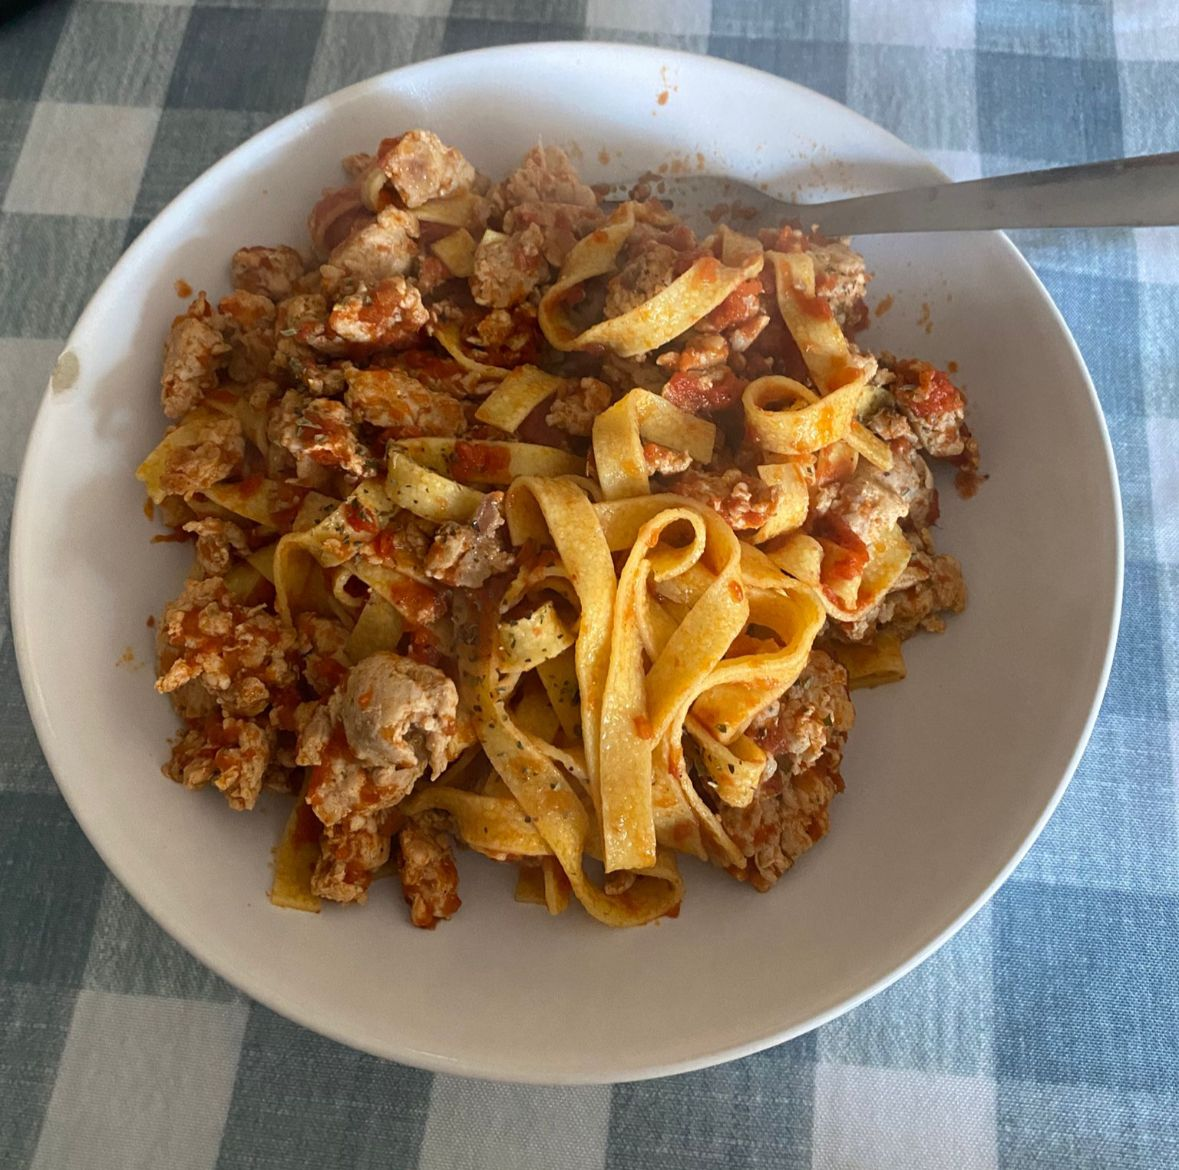

Loading Text Model: Qwen/Qwen2.5-3B-Instruct on cuda...


Loading weights: 100%|██████████| 434/434 [00:02<00:00, 191.67it/s]


Refining user input: 'Es una boloñesa y lleva 125 gramos de pasta'...
Refined context: 'Output: "Dish type: Bolognese, pasta weight: 125g."'
Unloading Text Model from VRAM...
Analyzing image with Qwen2-VL...

Plato: pasta with meat sauce (Confianza: high)


,name,grams,source
0,pasta,125,visible
1,meat,100,visible
2,tomato sauce,100,visible


In [6]:
# Ruta de la imagen
img_path = "images/boloñesa.jpeg" 
display(Image.open(img_path)) # Ver la foto

# Texto opcional del usuario
user_input = "Es una boloñesa y lleva 125 gramos de pasta"
#user_input = None # O déjalo en None si no quieres añadir nada

# Ejecutar el análisis completo
resultado = nutrition_system.analyze_food(img_path, user_context_text=user_input)

# Mostrar resultados
if "ingredients" in resultado:
    print(f"\nPlato: {resultado['dish_name']} (Confianza: {resultado['confidence']})")
    df = pd.DataFrame(resultado['ingredients'])
    display(df)
else:
    print(resultado)

In [ ]:
resultado

{'dish_name': 'Rice with vegetables and chicken',
 'dish_type': 'stew',
 'canonical_name': None,
 'ingredients': [{'name': 'chicken', 'grams': 100, 'source': 'visible'},
  {'name': 'green beans', 'grams': 50, 'source': 'visible'},
  {'name': 'carrots', 'grams': 25, 'source': 'visible'},
  {'name': 'rice', 'grams': 200, 'source': 'visible'}],
 'confidence': 'high'}

In [ ]:
import json
# with open("resultado.json", "r", encoding="utf-8") as f:
#     resultado = json.load(f)
# with open("resultado2.json", "w", encoding="utf-8") as f:
#     json.dump(resultado, f, ensure_ascii=False, indent=4)

## Cálculo de macros y calorías

In [8]:
from nutrition_lookup import analyze_meal, print_meal_summary

if "ingredients" not in resultado:
    print("El detector no devolvió ingredientes válidos.")
else:
    foods = [{"name": ing["name"], "grams": ing["grams"]} for ing in resultado["ingredients"]]
    
    result = analyze_meal(foods, nutrition_system=nutrition_system)
    print_meal_summary(result)
dish_name   = resultado["dish_name"]
foods       = [{"name": ing["name"], "grams": ing["grams"]} for ing in resultado["ingredients"]]

Loading Text Model: Qwen/Qwen2.5-3B-Instruct on cuda...


Loading weights: 100%|██████████| 434/434 [00:02<00:00, 173.26it/s]


  [LLM] Modelo de texto cargado para el lookup.

Buscando: 'pasta' (125g)
  [USDA] Similitud insuficiente (0.40) para 'pasta'
  [LLM] Consultando Qwen2.5-3B para 'pasta'...
  [LLM] 'pasta': 387.0 kcal/100g

Buscando: 'meat' (100g)
  [USDA] Similitud insuficiente (0.47) para 'meat'
  [LLM] Consultando Qwen2.5-3B para 'meat'...
  [LLM] 'meat': 175.0 kcal/100g

Buscando: 'tomato sauce' (100g)
  [USDA] Similitud insuficiente (0.57) para 'tomato sauce'
  [LLM] Consultando Qwen2.5-3B para 'tomato sauce'...
  [LLM] 'tomato sauce': 161.0 kcal/100g
Unloading Text Model from VRAM...
  [LLM] Modelo de texto descargado.

══════════════════════════════════════════════════════════
  RESUMEN NUTRICIONAL DE LA COMIDA
══════════════════════════════════════════════════════════

  ⚠️  Pasta (125g)  [LLM (estimado)]
     Kcal:     483.8 kcal
     Proteína: 8.6 g
     Carbos:   85.2 g
     Grasa:    3.1 g
     Fibra:    3.2 g

  ⚠️  Meat (100g)  [LLM (estimado)]
     Kcal:     175.0 kcal
     Proteína: 20.

## Guardar datos

In [ ]:
def save_meal(data, filename="meals.json"):
    now = datetime.now()
    date_str = now.strftime("%Y-%m-%d")
    time_str = now.strftime("%H:%M:%S")

    # Añadir hora al registro
    data["time"] = time_str

    # Cargar archivo existente
    if os.path.exists(filename):
        with open(filename, "r") as f:
            db = json.load(f)
    else:
        db = {}

    # Si no existe el día, crearlo
    if date_str not in db:
        db[date_str] = []

    # Añadir comida
    db[date_str].append(data)

    # Guardar
    with open(filename, "w") as f:
        json.dump(db, f, indent=4)

    print(f"Guardado en {date_str} a las {time_str}")

save_meal({
    "dish_name":   dish_name,
    "ingredients": foods,
    "nutrition":   result       
})



Guardado en 2026-03-26 a las 17:44:18


In [4]:
nueva_receta=check_and_suggest(
    model            = nutrition_system.v_model,
    processor_or_tok = nutrition_system.v_processor,
    meals_file="meals.json",
    user_file= "user.json",
    force = False
)


⚡ Trigger activo: ≤25 % kcal restantes (38.1 % = 750 kcal)
🍽️  Generando sugerencia de plato...
  [LLM] Generando sugerencia...

  Verificando 4 ingrediente(s) en USDA/OFF...
  [USDA] Similitud insuficiente (0.55) para 'salmon'
  [LLM] Modelo de texto no disponible para 'salmon'
  ✗ 'salmon' no encontrado. Omitido.
  [USDA] Sin match confiable para 'mixed greens' → fallback LLM
  [LLM] Modelo de texto no disponible para 'mixed greens'
  ✗ 'mixed greens' no encontrado. Omitido.
  [USDA] 'avocado' → 'Oil, avocado' (similitud 0.74)
  [USDA] Similitud insuficiente (0.57) para 'orange'
  [LLM] Modelo de texto no disponible para 'orange'
  ✗ 'orange' no encontrado. Omitido.

══════════════════════════════════════════════════════════
  SUGERENCIA DE PLATO
══════════════════════════════════════════════════════════
  ⚡ Motivo:  ≤25 % kcal restantes (38.1 % = 750 kcal)

  🍽️  Grilled Salmon Salad  (50g)
  💬 This salad provides protein from grilled salmon, healthy fats from avocado, and fiber-ri

In [5]:
nueva_receta

{'dish_name': 'Grilled Salmon Salad',
 'total_grams': 50.0,
 'reason': 'This salad provides protein from grilled salmon, healthy fats from avocado, and fiber-rich carbs from mixed greens.',
 'ingredients_verified': [{'name': 'salmon',
   'grams': 90.0,
   'source': None,
   'error': 'No encontrado'},
  {'name': 'mixed greens',
   'grams': 100.0,
   'source': None,
   'error': 'No encontrado'},
  {'name': 'avocado',
   'grams': 50.0,
   'source': 'USDA',
   'kcal': 442.0,
   'protein_g': 0.0,
   'fat_g': 50.0,
   'carbs_g': 0.0,
   'fiber_g': 0.0,
   'sugar_g': 0.0,
   'sodium_mg': 0.0},
  {'name': 'orange', 'grams': 50.0, 'source': None, 'error': 'No encontrado'}],
 'totals_verified': {'kcal': 442.0,
  'protein_g': 0.0,
  'fat_g': 50.0,
  'carbs_g': 0.0,
  'fiber_g': 0.0,
  'sugar_g': 0.0,
  'sodium_mg': 0.0},
 'trigger_reason': '≤25 % kcal restantes (38.1 % = 750 kcal)',
 'remaining_before': {'kcal': 750.2,
  'protein_g': 16.5,
  'carbs_g': 155.5,
  'fat_g': 26.9}}

In [6]:
import pandas as pd

data = nueva_receta  

rows = []
for ing in data["ingredients_verified"]:
    rows.append({
        "Ingrediente": ing["name"],
        "Cantidad (g)": ing["grams"],
        "Calorías (kcal)": ing.get("kcal", None)
    })

df = pd.DataFrame(rows)
print(df)

    Ingrediente  Cantidad (g)  Calorías (kcal)
0        salmon          90.0              NaN
1  mixed greens         100.0              NaN
2       avocado          50.0            442.0
3        orange          50.0              NaN


## Resumen diario

In [10]:
def get_daily_summary(date, meals_file="meals.json", user_file="user.json"):

    with open(meals_file, "r") as f:
        meals_db = json.load(f)

    with open(user_file, "r") as f:
        user = json.load(f)

    meals = meals_db.get(date, [])

    total = {
        "kcal": 0,
        "protein_g": 0,
        "carbs_g": 0,
        "fat_g": 0
    }

    for meal in meals:
        nutr = meal["nutrition"]["totals"]

        total["kcal"] += nutr.get("kcal", 0)
        total["protein_g"] += nutr.get("protein_g", 0)
        total["carbs_g"] += nutr.get("carbs_g", 0)
        total["fat_g"] += nutr.get("fat_g", 0)

    targets = user["daily_targets"]

    return {
        "total": total,
        "targets": targets,
        "remaining": {
            key: targets[key] - total[key]
            for key in targets
        }
    }


def compute_percentages(total, targets):
    percentages = {}

    for key in targets:
        if targets[key] > 0:
            percentages[key] = total[key] / targets[key]
        else:
            percentages[key] = 0

    return percentages



def plot_radar(percentages):
    labels = list(percentages.keys())
    values = list(percentages.values())

    # Cerrar el círculo
    values += values[:1]
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    line_color = "#E07A5F"  
    fill_color = "#F2CC8F"   
    grid_color = "#EAE2D6"  

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

    ax.spines["polar"].set_visible(False)

    ax.grid(color=grid_color, linewidth=1)

    # Plot principal
    ax.plot(angles, values, linewidth=2.5, color=line_color)
    ax.fill(angles, values, color=fill_color, alpha=0.6)

    # Etiquetas
    pretty_labels = {
        "kcal": "Calories",
        "protein_g": "Protein",
        "carbs_g": "Carbs",
        "fat_g": "Fat"
    }

    display_labels = [pretty_labels.get(l, l) for l in labels]

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(display_labels, fontsize=11)

    # Límites
    ax.set_ylim(0, 1.5)

    ax.plot(angles, [1]*len(angles), linestyle="dashed", linewidth=2, color="#81B29A")
    ax.text(0, 1.05, "Target", color="#81B29A", fontsize=10)

    ax.set_yticklabels([])

    # Título
    plt.title("Daily Nutrition Balance (%)", fontsize=14, weight="bold", pad=20)

    plt.show()

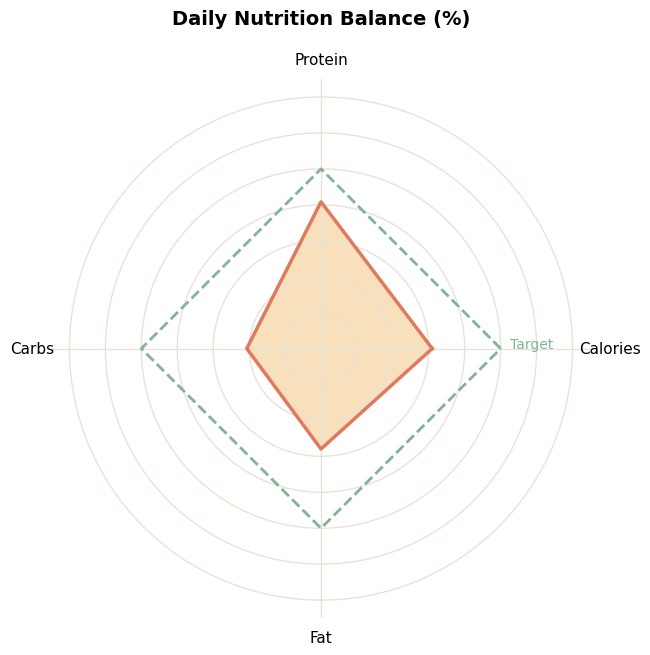

In [28]:
summary =get_daily_summary(date=datetime.now().strftime("%Y-%m-%d"),meals_file="meals.json", user_file="user.json")
summary 
percentages = compute_percentages(
    summary["total"],
    summary["targets"]
)

plot_radar(percentages)

In [29]:
summary

{'total': {'kcal': 1218.8, 'protein_g': 73.5, 'carbs_g': 109.5, 'fat_g': 34.1},
 'targets': {'kcal': 1969, 'protein_g': 90, 'carbs_g': 265, 'fat_g': 61},
 'remaining': {'kcal': 750.2,
  'protein_g': 16.5,
  'carbs_g': 155.5,
  'fat_g': 26.9}}